In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Understanding Data

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Data Preprocessing

In [6]:
# Remove rows with negative quantity (cancellations)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
# Remove rows with zero or negative quantity
df = df[df['Quantity'] > 0]

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description       592
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133361
Country             0
dtype: int64

In [9]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [10]:
# Convert 'InvoiceDate' to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
# Check for missing values in 'CustomerID'
df['CustomerID'].isnull().sum()

np.int64(133361)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 531285 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    531285 non-null  str           
 1   StockCode    531285 non-null  str           
 2   Description  530693 non-null  str           
 3   Quantity     531285 non-null  int64         
 4   InvoiceDate  531285 non-null  datetime64[us]
 5   UnitPrice    531285 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      531285 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.5 MB


In [13]:
print("Negative Unit Prices found <= 0:", df[df['UnitPrice'] <= 0].shape[0])

Negative Unit Prices found <= 0: 1181


In [14]:
print("Large Quantities found > 1000:", (df['Quantity'] > 1000).sum())

Large Quantities found > 1000: 116


### Insights
1. The dataset has 541909 rows & 8 columns
2. Removed rows with negative quantity (cancellations)
3. Removed rows with zero or negative quantity
4. Description has 592 & CustomerID has 133361 null values
5. Converted 'InvoiceDate' to datetime
6. 1181 Negative Unit Prices found
7. 116 Large Quantities found > 1000

In [15]:
# Dropped rows with missing 'Description' or 'CustomerID'
df = df.dropna(subset=['Description'])
df = df.dropna(subset=['CustomerID'])

In [16]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
# Remove rows with zero or negative quantity
df = df[df['UnitPrice'] > 0]

In [18]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Data preprocessing result 
1. Removed invalid transactions 
2. Handled Missing Customer IDs, 
3. Constructed revenue-based features TotalPrice for CLV modeling

# Feature Engineering

#### Goal is creating new features:
* Recency 
* Frequency 
* Monetary 

In [20]:
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
current_date

Timestamp('2011-12-10 12:50:00')

In [21]:
# RFM Calculation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days, # current date - most recent purchase date
    'InvoiceNo': 'nunique', # number of unique invoices
    'TotalPrice': 'sum' # sum of money spent
})

In [22]:
# Renamed columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [23]:
# RFM table
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


`Recency` -> How recently they buy

1. High recency -> bad (inactive customer)
2. Low recency -> good (active customer)

`Frequency` -> How often they buy

3. High frequency -> loyal customer (purchases often)
4. Low frequency -> one time buyer (purchases not so often)

`Monetary` -> How much a customer spend

5. High monetary -> valuable customer
6. Low monetary -> low value customer

Text(0.5, 1.0, 'Distribution of Recency')

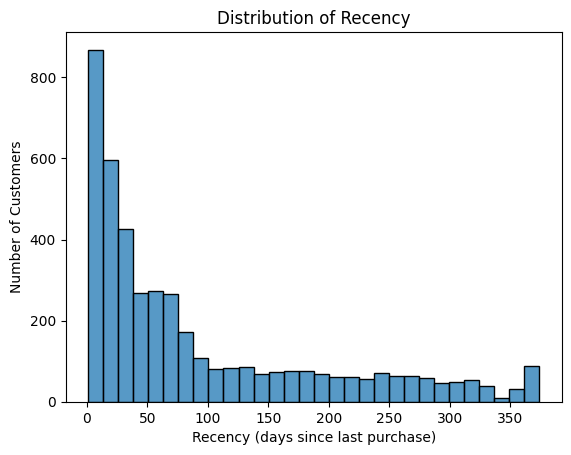

In [24]:
sns.histplot(rfm['Recency'], bins=30)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Recency')

Text(0.5, 1.0, 'Distribution of Frequency')

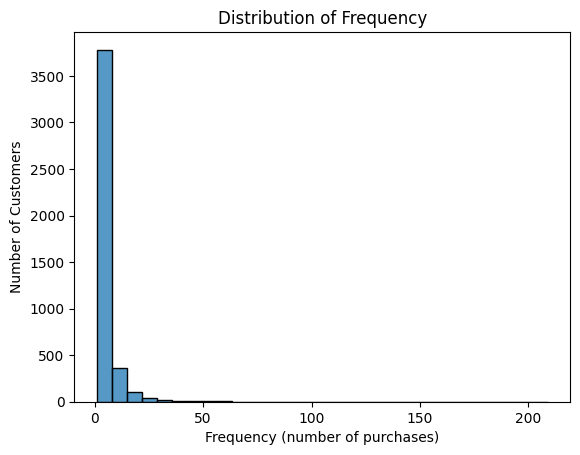

In [25]:
sns.histplot(rfm['Frequency'], bins=30)
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Frequency')

Text(0.5, 1.0, 'Distribution of Monetary Value')

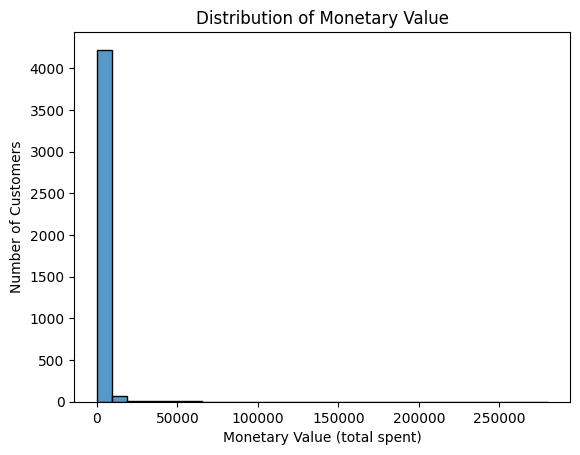

In [26]:
sns.histplot(rfm['Monetary'], bins=30)
plt.xlabel('Monetary Value (total spent)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monetary Value')

In [27]:
# Create time split for last 90 days
split_date = df['InvoiceDate'].max() - pd.Timedelta(days=90)
split_date

Timestamp('2011-09-10 12:50:00')

In [28]:
# Create future dataframe for past 90 days
train_df = df[df['InvoiceDate'] <= split_date]
train_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [29]:
# Create future dataframe for next 90 days
future_df = df[df['InvoiceDate'] > split_date]
future_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
334054,566225,22384,LUNCH BAG PINK POLKADOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90
334055,566225,20725,LUNCH BAG RED RETROSPOT,6,2011-09-11 10:35:00,1.65,16899.0,United Kingdom,9.90
334056,566225,23169,CLASSIC GLASS COOKIE JAR,3,2011-09-11 10:35:00,4.15,16899.0,United Kingdom,12.45
334057,566225,84029E,RED WOOLLY HOTTIE WHITE HEART.,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75
334058,566225,21479,WHITE SKULL HOT WATER BOTTLE,3,2011-09-11 10:35:00,4.25,16899.0,United Kingdom,12.75


In [30]:
# RFM calculation for training data
rfm_train = train_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (split_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm_train.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [31]:
# Calculate CLV for future dataframe
clv = future_df.groupby('CustomerID')['TotalPrice'].sum()
clv = clv.reset_index()
clv.columns = ['CustomerID', 'CLV']
clv.head()

,CustomerID,CLV
0,12347.0,1519.14
1,12348.0,310.00
2,12349.0,1757.55
3,12352.0,944.23
4,12356.0,58.35


In [32]:
# Merge Features and Target
final_df = rfm_train.merge(clv, on='CustomerID', how='left')

# Fill customers with no future purchases
final_df['CLV'] = final_df['CLV'].fillna(0)

In [33]:
final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


<Axes: >

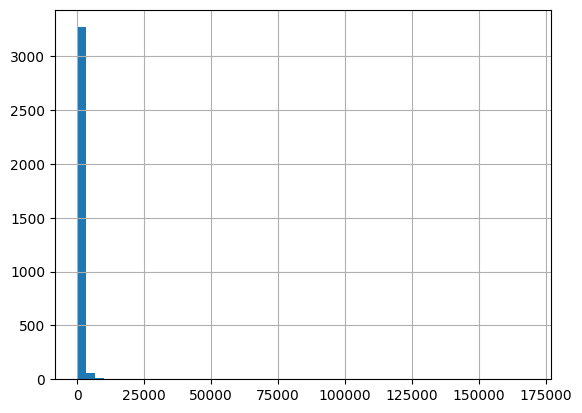

In [34]:
# CLV distribution
final_df['CLV'].hist(bins=50)

# Log Transformation

Problems that will occur if we skipped log:
* Model gets biased toward large values
* Poor predictions for normal customers
* High error due to variance imbalance

In [35]:
final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV
0,12346.0,235,1,77183.60,0.00
1,12347.0,39,5,2790.86,1519.14
2,12348.0,158,3,1487.24,310.00
3,12350.0,219,1,334.40,0.00
4,12352.0,171,5,1561.81,944.23


In [36]:
final_df['Recency_log'] = np.log1p(final_df['Recency'])
final_df['Frequency_log'] = np.log1p(final_df['Frequency'])
final_df['Monetary_log'] = np.log1p(final_df['Monetary'])
final_df['CLV_log'] = np.log1p(final_df['CLV'])

In [37]:
final_df.head()

,CustomerID,Recency,Frequency,Monetary,CLV,Recency_log,Frequency_log,Monetary_log,CLV_log
0,12346.0,235,1,77183.60,0.00,5.463832,0.693147,11.253955,0.000000
1,12347.0,39,5,2790.86,1519.14,3.688879,1.791759,7.934463,7.326558
2,12348.0,158,3,1487.24,310.00,5.068904,1.386294,7.305349,5.739793
3,12350.0,219,1,334.40,0.00,5.393628,0.693147,5.815324,0.000000
4,12352.0,171,5,1561.81,944.23,5.147494,1.791759,7.354241,6.851428


# Model Training

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Recency_log', 'Frequency_log', 'Monetary_log']

# Split the unscaled data first
X_train, X_test, y_train, y_test = train_test_split(
    final_df[features], final_df['CLV_log'], test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [39]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Define the models
models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

results = []

# Train and evaluate
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)

    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)
    
    rmse = root_mean_squared_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test, y_pred_log)
    results.append((name, rmse, r2))

# Display the results sorted by R2
results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2'])
results_df.sort_values(by='R2', ascending=False)

Training Linear Regression...
Training Gradient Boosting...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...
Training Decision Tree...


,Model,RMSE,R2
1,Gradient Boosting,6995.979933,0.222874
2,Ridge Regression,9118.138106,0.214002
0,Linear Regression,9128.648845,0.213988
3,Lasso Regression,8107.325144,0.141495
4,Random Forest,6802.769322,0.114907
5,Decision Tree,7672.056719,-0.540493


# Hyperparameter Optimization

In [40]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define the models and the parameters we want to test for each
optimization_configs = {
    "Ridge Regression": {
        "model": Ridge(random_state=42),
        "params": {"alpha": [0.1, 1.0, 10.0, 100.0]}
    },
    "Lasso Regression": {
        "model": Lasso(random_state=42),
        "params": {"alpha": [0.01, 0.1, 1.0, 10.0]}
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [5, 10, 20, None], 
            "min_samples_split": [2, 10, 50]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100], 
            "max_depth": [10, 20, None], 
            "min_samples_split": [2, 10]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 150], 
            "learning_rate": [0.05, 0.1, 0.2], 
            "max_depth": [3, 5, 7]
        }
    }
}

In [41]:
tuned_results = []

print("Starting hyperparameter tuning...\n")

for name, config in optimization_configs.items():
    print(f"Tuning {name}...")
    
    # 1. Setup the Search Strategy
    if name in ["Random Forest", "Gradient Boosting", "Decision Tree"]:
        search = RandomizedSearchCV(
            config["model"], 
            config["params"], 
            n_iter=5,        # Number of random combinations to try
            cv=3,            # 3-fold cross validation
            scoring='r2', 
            random_state=42, 
            n_jobs=-1   
        )
    else:
        search = GridSearchCV(
            config["model"], 
            config["params"], 
            cv=3, 
            scoring='r2', 
            n_jobs=-1
        )
        
    # 2. Fit the search to the training data
    search.fit(X_train, y_train)
    
    # 3. Extract the absolute best model it found
    best_model = search.best_estimator_
    
    # 4. Test this best model on our unseen test data
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    # 5. Save the results
    tuned_results.append({
        "Model": name,
        "Best Parameters": search.best_params_,
        "Tuned R2": r2,
        "Tuned RMSE": rmse
    })
    print(f"Finished {name} - Best R2: {r2:.4f}\n")

Starting hyperparameter tuning...

Tuning Ridge Regression...
Finished Ridge Regression - Best R2: 0.2142

Tuning Lasso Regression...
Finished Lasso Regression - Best R2: 0.2145

Tuning Decision Tree...
Finished Decision Tree - Best R2: 0.1963

Tuning Random Forest...
Finished Random Forest - Best R2: 0.1956

Tuning Gradient Boosting...
Finished Gradient Boosting - Best R2: 0.2300



In [42]:
results_df = pd.DataFrame(tuned_results)
results_df = results_df.sort_values(by="Tuned R2", ascending=False)

# Display the final leaderboard
display(results_df)

,Model,Best Parameters,Tuned R2,Tuned RMSE
4,Gradient Boosting,"{'n_estimators': 50, 'max_depth': 3, 'learning...",0.230039,2.889481
1,Lasso Regression,{'alpha': 0.01},0.214454,2.918578
0,Ridge Regression,{'alpha': 10.0},0.214222,2.919009
2,Decision Tree,"{'min_samples_split': 2, 'max_depth': 5}",0.196331,2.952054
3,Random Forest,"{'n_estimators': 50, 'min_samples_split': 2, '...",0.195609,2.953380


In [43]:
results_df = results_df.sort_values(by="Tuned RMSE", ascending=True)
best_model_row = results_df.iloc[0]

winner_name = best_model_row['Model']

print("Final Winner Model")
print("-" * 32)
print(f"The Winner is: {winner_name}")

Final Winner Model
--------------------------------
The Winner is: Gradient Boosting
